
<h1 style="color:#ffffff; background-color:#153B32; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">
Day 5 — Advancing the Core Model &amp; Sprint 2 Review
</h1>
<h3 style="color:#2F6B5B; text-align:center; font-weight:bold; margin-top:0;">
MobileNetV2 Tuning, Experiment Logging, Final Evaluation, Sprint Review &amp; Retrospective
</h3>



<a id="toc"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ul style="font-weight:bold; line-height:1.9; color:#24312D;">
<li><a href="#section0">0. Setup — Imports, Reproducibility & Runtime</a></li>
<li><a href="#section1">1. Sprint 2 Goal & Day 2 Evidence</a></li>
<li><a href="#section2">2. Confirm the Core Architecture</a></li>
<li><a href="#section3">3. Load the Day 2 Image Dataset</a></li>
<li><a href="#section4">4. Build Reproducible TensorFlow Datasets</a></li>
<li><a href="#section5">5. Day 5 Experiment Plan</a></li>
<li><a href="#section6">6. MobileNetV2 Experiment Framework</a></li>
<li><a href="#section7">7. Run Controlled Fine-Tuning Experiments</a></li>
<li><a href="#section8">8. Experiment Log & Validation-Based Selection</a></li>
<li><a href="#section9">9. Final Test Evaluation of the Selected Model</a></li>
<li><a href="#section10">10. Threshold Analysis</a></li>
<li><a href="#section11">11. Sprint 2 Model Comparison</a></li>
<li><a href="#section13">13. Sprint Review</a></li>
<li><a href="#section14">14. Retrospective</a></li>
<li><a href="#section16">16. What I Learned Today</a></li>
</ul>
</div>



<a id="section0"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Imports, Reproducibility &amp; Runtime</h2>

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>Goal:</b> Continue from the strongest documented Day 2 model, run controlled tuning experiments,
select the best configuration using <b>validation performance</b>, and use the test set only for the final evaluation.
</div>


In [1]:
# Core imports
import time
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available      :", bool(tf.config.list_physical_devices("GPU")))
print("GPU devices        :", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU available      : False
GPU devices        : []



<div style="border-left:5px solid #D8A94A; background-color:#FFF7E1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#6A5420;">
<b>Reproducibility:</b> The same seed, validation split, image size, batch size, preprocessing,
and test set are kept across experiments. Only the planned tuning variable changes.
</div>



<a id="section1"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Sprint 2 Goal &amp; Day 2 Evidence</h2>

The Day 2 notebook tested four image-classification approaches on the Benign/Malignant dataset.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Day 2 Model</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Test Accuracy</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Test AUC</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Precision</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Recall</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Scratch CNN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7805</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8838</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8288</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7070</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">CNN + Augmentation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7295</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8195</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7302</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7280</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Frozen MobileNetV2</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8480</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.9390</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.9123</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7700</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>MobileNetV2 + Fine-Tuning</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>0.8625</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>0.9499</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>0.9191</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>0.7950</b></td></tr>
</table>
</div>

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>Starting point for Day 5:</b> MobileNetV2 + Fine-Tuning was the strongest documented Day 2 model.
Day 5 therefore treats it as the current core-model reference and tries to improve it systematically.
</div>

<div style="border-left:5px solid #D96C5F; background-color:#FCEDEA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7C3A33;">
<b>Baseline note:</b> There is no documented Week 6 baseline available in this project history.
This notebook does not invent one. The Day 2 Scratch CNN is shown only as a documented internal reference,
while the Day 2 fine-tuned MobileNetV2 is the model Day 5 aims to advance.
</div>



<a id="section2"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Confirm the Core Architecture</h2>

The project data type determines the architecture choice.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr><th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Data Type</th><th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Suitable Core Architecture</th><th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Decision</th></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Tabular</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Dense network / gradient boosting</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Not our data type</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>Images</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>CNN + Transfer Learning</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>Selected</b></td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Text</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">LSTM / pre-trained Transformer</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Not our capstone data type</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Sequence / Time Series</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">LSTM / GRU</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Not our data type</td></tr>
</table>
</div>

<div style="display:flex; flex-wrap:wrap; align-items:center; gap:8px; justify-content:center; margin:15px 0;">
<div style="background:#EDF6F3; border:1px solid #BFD7CF; padding:10px 14px; border-radius:10px; font-weight:bold; color:#153B32;">Skin Lesion Images</div>
<div style="font-size:22px; color:#2F6B5B;">→</div>
<div style="background:#FFF7E1; border:1px solid #E4CE8E; padding:10px 14px; border-radius:10px; font-weight:bold; color:#6A5420;">CNN</div>
<div style="font-size:22px; color:#2F6B5B;">→</div>
<div style="background:#EAF5F1; border:1px solid #BFD7CF; padding:10px 14px; border-radius:10px; font-weight:bold; color:#24554A;">MobileNetV2 Transfer Learning</div>
<div style="font-size:22px; color:#2F6B5B;">→</div>
<div style="background:#FCEDEA; border:1px solid #E7B9B2; padding:10px 14px; border-radius:10px; font-weight:bold; color:#7C3A33;">Benign / Malignant</div>
</div>

<b>Architecture decision:</b> The core model remains a CNN with transfer learning because the capstone input is image data.
The RNN/LSTM and Transformer work from Days 3–4 was a curriculum learning lab for sequential/text data, not a replacement
for the image architecture.



<a id="section3"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Load the Day 2 Image Dataset</h2>

This notebook is designed for the following structure:

<pre style="background-color:#F7F9F8; border:1px solid #D9E4E0; padding:14px; border-radius:6px; color:#24312D;">
Week 7/
├── Day 2/
│   ├── dataset/
│   │   ├── train/
│   │   │   ├── Benign/
│   │   │   └── Malignant/
│   │   └── test/
│   │       ├── Benign/
│   │       └── Malignant/
│   └── Day2.ipynb
│
└── Day 5/
    └── Day5.ipynb
</pre>

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>No duplicate dataset:</b> Day 5 reuses the dataset stored inside the Day 2 folder.
</div>


In [2]:
# Robustly locate Day 2's dataset from either:
# 1) a kernel started inside Day 5, or
# 2) a kernel started from the Week 7 folder.

cwd = Path.cwd()

dataset_candidates = [
    cwd.parent / "Day 2" / "dataset",
    cwd / "Day 2" / "dataset",
    cwd / "dataset",  # fallback if the notebook is intentionally run beside a dataset folder
]

DATASET_ROOT = next((p.resolve() for p in dataset_candidates if p.exists()), None)

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Could not find the image dataset.\n"
        "Expected Day 2/dataset to exist as a sibling of Day 5."
    )

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

required_folders = [
    TRAIN_DIR / "Benign",
    TRAIN_DIR / "Malignant",
    TEST_DIR / "Benign",
    TEST_DIR / "Malignant",
]

missing = [folder for folder in required_folders if not folder.exists()]
if missing:
    raise FileNotFoundError(
        "Dataset structure is incomplete:\n" +
        "\n".join(str(folder) for folder in missing)
    )

print("Current working directory:", cwd)
print("Dataset root             :", DATASET_ROOT)


Current working directory: c:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 7\Day 5
Dataset root             : C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 7\Day 2\dataset


In [3]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def count_images(folder):
    return sum(
        1
        for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )

count_rows = []

for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_name in ["Benign", "Malignant"]:
        count_rows.append({
            "split": split_name,
            "class": class_name,
            "images": count_images(split_dir / class_name),
        })

counts_df = pd.DataFrame(count_rows)
display(counts_df)

print("Total images:", int(counts_df["images"].sum()))


,split,class,images
0,train,Benign,6289
1,train,Malignant,5590
2,test,Benign,1000
3,test,Malignant,1000


Total images: 13879



<div style="border-left:5px solid #D8A94A; background-color:#FFF7E1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#6A5420;">
<b>Expected documented counts from Day 2:</b> 6,289 Benign + 5,590 Malignant training images,
and 1,000 Benign + 1,000 Malignant test images.
</div>



<a id="section4"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Build Reproducible TensorFlow Datasets</h2>

Day 5 keeps the same core data settings used in Day 2:

- image size = <code>160 × 160</code>
- batch size = <code>32</code>
- validation split = <code>20%</code>
- binary labels
- fixed seed
- test set with <code>shuffle=False</code>


In [4]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print("Class names:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.
Class names: ['Benign', 'Malignant']



<a id="section5"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Day 5 Experiment Plan</h2>

Instead of changing many things at once, the tuning plan changes one main variable at a time.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Experiment</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Fine-Tune Layers</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Fine-Tune LR</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Dropout</th>
<th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Purpose</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>A — Day 2 Control</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">30</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">1e-5</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.30</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Reproduce the Day 2 fine-tuning design</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>B — Lower LR</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">30</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">5e-6</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.30</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Test gentler fine-tuning</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>C — Deeper Fine-Tuning</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">40</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">5e-6</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.30</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Test whether adapting more upper layers helps</td></tr>
</table>
</div>

<div style="border-left:5px solid #D96C5F; background-color:#FCEDEA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7C3A33;">
<b>Selection rule:</b> The best Day 5 experiment is selected using <b>validation AUC</b>, not test accuracy.
The test set stays untouched until one experiment has been selected.
</div>

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>Why AUC?</b> It evaluates how well the model ranks the two classes across thresholds and complements accuracy.
Validation recall is also logged because the positive class is Malignant in this dataset mapping.
</div>



<a id="section6"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. MobileNetV2 Experiment Framework</h2>

<h3 style="color:#F6E7B0; font-weight:bold; background-color:#1F4E43; display:inline-block; padding:4px 10px; border-radius:6px;">6.1 Keep the Day 2 augmentation pipeline</h3>


In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")



<h3 style="color:#F6E7B0; font-weight:bold; background-color:#1F4E43; display:inline-block; padding:4px 10px; border-radius:6px;">6.2 Build and compile the transfer-learning model</h3>


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def compile_binary_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


def build_transfer_model(dropout_rate=0.30):
    backbone = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
    )

    backbone.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_sprint2")
    compile_binary_model(model, learning_rate=1e-3)

    return model, backbone



<h3 style="color:#F6E7B0; font-weight:bold; background-color:#1F4E43; display:inline-block; padding:4px 10px; border-radius:6px;">6.3 Training, logging, plotting &amp; model-saving helpers</h3>


In [7]:
ARTIFACTS_DIR = Path("artifacts")
MODELS_DIR = ARTIFACTS_DIR / "models"

ARTIFACTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        )
    ]


def combine_histories(*histories):
    combined = {}

    for history in histories:
        for key, values in history.history.items():
            combined.setdefault(key, []).extend(values)

    return combined


def plot_combined_history(history, title):
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["auc"], label="Train AUC")
    plt.plot(epochs, history["val_auc"], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{title} — AUC")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def count_trainable_parameters(model):
    return int(sum(np.prod(v.shape) for v in model.trainable_weights))


In [8]:
def run_experiment(
    name,
    fine_tune_layers,
    fine_tune_lr,
    dropout_rate=0.30,
    head_epochs=3,
    fine_tune_epochs=4,
):
    print("=" * 80)
    print("Running:", name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    # Step 1 — fresh ImageNet MobileNetV2 + new classifier head
    model, backbone = build_transfer_model(dropout_rate=dropout_rate)

    start = time.perf_counter()

    head_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=head_epochs,
        callbacks=make_callbacks(),
        verbose=1,
    )

    # Step 2 — controlled fine-tuning
    backbone.trainable = True
    fine_tune_at = max(0, len(backbone.layers) - fine_tune_layers)

    for layer in backbone.layers[:fine_tune_at]:
        layer.trainable = False

    # Keep BatchNormalization frozen for stable fine-tuning.
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    compile_binary_model(model, learning_rate=fine_tune_lr)

    initial_epoch = len(head_history.epoch)

    fine_history = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=initial_epoch,
        epochs=initial_epoch + fine_tune_epochs,
        callbacks=make_callbacks(),
        verbose=1,
    )

    elapsed = time.perf_counter() - start
    history = combine_histories(head_history, fine_history)

    row = {
        "experiment": name,
        "fine_tune_layers": fine_tune_layers,
        "fine_tune_lr": fine_tune_lr,
        "dropout": dropout_rate,
        "epochs_run": len(history["loss"]),
        "best_val_auc": float(np.max(history["val_auc"])),
        "best_val_accuracy": float(np.max(history["val_accuracy"])),
        "best_val_recall": float(np.max(history["val_recall"])),
        "best_val_precision": float(np.max(history["val_precision"])),
        "training_seconds": float(elapsed),
        "trainable_parameters": count_trainable_parameters(model),
    }

    model_path = MODELS_DIR / f"{name.lower().replace(' ', '_').replace('—', '').replace('/', '_')}.keras"
    model.save(model_path)

    print("\nSaved model:", model_path)
    print("Best validation AUC:", f'{row["best_val_auc"]:.4f}')

    return row, history, model_path



<a id="section7"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Run Controlled Fine-Tuning Experiments</h2>

<div style="border-left:5px solid #D8A94A; background-color:#FFF7E1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#6A5420;">
<b>Runtime note:</b> These experiments train real MobileNetV2 models and can take significant time on CPU.
Run the cell once and keep the generated <code>artifacts/models</code> files so you do not need to repeat training unnecessarily.
</div>


In [9]:
EXPERIMENTS = [
    {
        "name": "A - Day2 Control",
        "fine_tune_layers": 30,
        "fine_tune_lr": 1e-5,
        "dropout_rate": 0.30,
    },
    {
        "name": "B - Lower LR",
        "fine_tune_layers": 30,
        "fine_tune_lr": 5e-6,
        "dropout_rate": 0.30,
    },
    {
        "name": "C - Deeper Fine-Tuning",
        "fine_tune_layers": 40,
        "fine_tune_lr": 5e-6,
        "dropout_rate": 0.30,
    },
]

experiment_rows = []
experiment_histories = {}
experiment_model_paths = {}

for config in EXPERIMENTS:
    row, history, model_path = run_experiment(**config)

    experiment_rows.append(row)
    experiment_histories[config["name"]] = history
    experiment_model_paths[config["name"]] = model_path

experiment_log = pd.DataFrame(experiment_rows)
experiment_log


Running: A - Day2 Control

Epoch 1/3


c:\Users\sadee\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.7799 - auc: 0.8617 - loss: 0.4628 - precision: 0.7806 - recall: 0.7363 - val_accuracy: 0.8333 - val_auc: 0.9191 - val_loss: 0.3584 - val_precision: 0.8371 - val_recall: 0.8122
Epoch 2/3
297/297 ━━━━━━━━━━━━━━━━━━━━ 92s 310ms/step - accuracy: 0.8273 - auc: 0.9070 - loss: 0.3845 - precision: 0.8299 - recall: 0.7935 - val_accuracy: 0.8467 - val_auc: 0.9271 - val_loss: 0.3541 - val_precision: 0.8989 - val_recall: 0.7686
Epoch 3/3
297/297 ━━━━━━━━━━━━━━━━━━━━ 148s 498ms/step - accuracy: 0.8372 - auc: 0.9158 - loss: 0.3650 - precision: 0.8401 - recall: 0.8052 - val_accuracy: 0.8480 - val_auc: 0.9271 - val_loss: 0.3474 - val_precision: 0.8866 - val_recall: 0.7852
Restoring model weights from the end of the best epoch: 2.
Epoch 4/7
297/297 ━━━━━━━━━━━━━━━━━━━━ 192s 589ms/step - accuracy: 0.8474 - auc: 0.9234 - loss: 0.3490 - precision: 0.8526 - recall: 0.8146 - val_accuracy: 0.8493 - val_auc: 0.9328 - val_loss: 0.3317 - val_precision: 0

,experiment,fine_tune_layers,fine_tune_lr,dropout,epochs_run,best_val_auc,best_val_accuracy,best_val_recall,best_val_precision,training_seconds,trainable_parameters
0,A - Day2 Control,30,0.000010,0.3,7,0.942024,0.858105,0.813974,0.917548,963.261718,1512001
1,B - Lower LR,30,0.000005,0.3,7,0.940092,0.857684,0.807860,0.910352,1118.070322,1512001
2,C - Deeper Fine-Tuning,40,0.000005,0.3,7,0.940518,0.854737,0.780786,0.923503,1224.392891,1664641


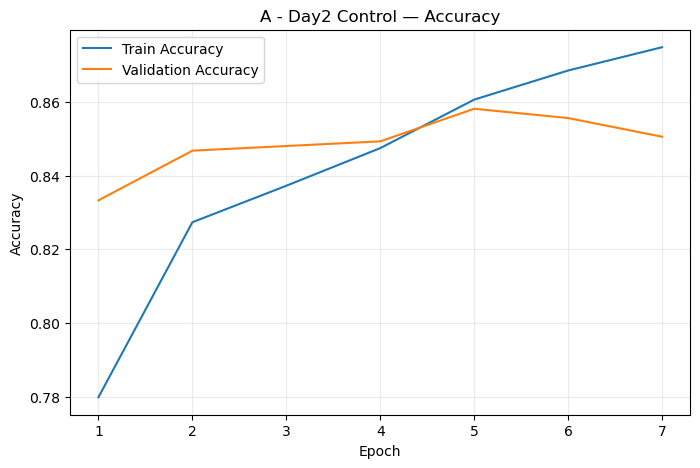

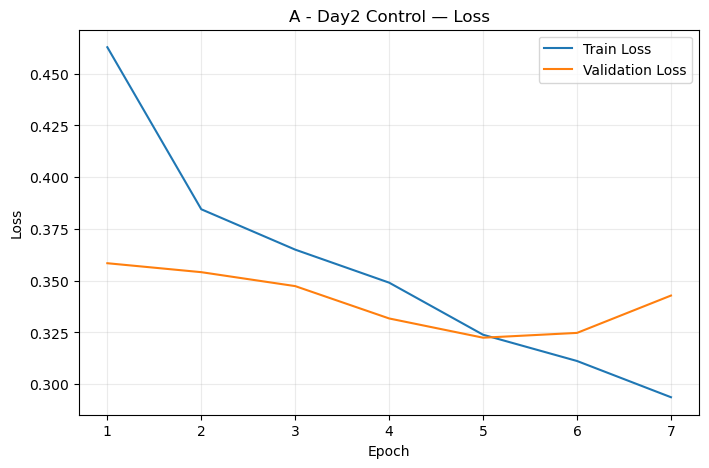

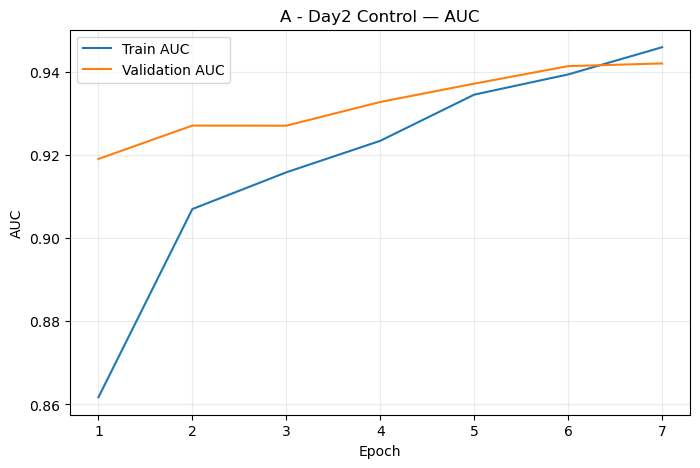

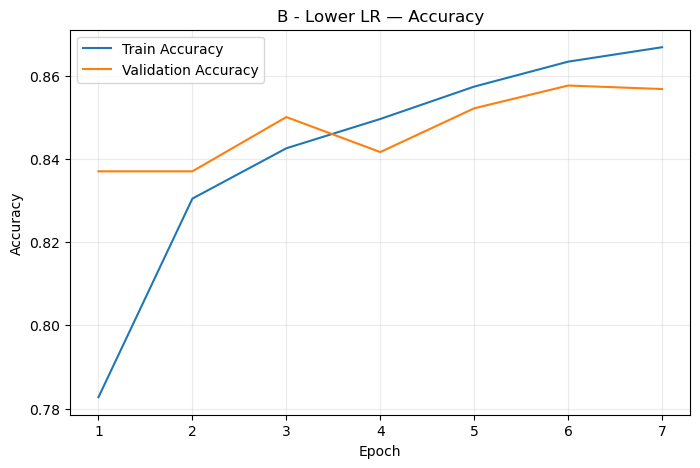

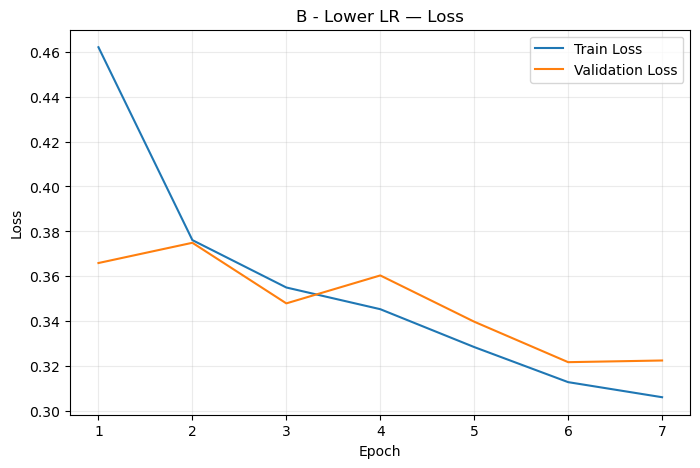

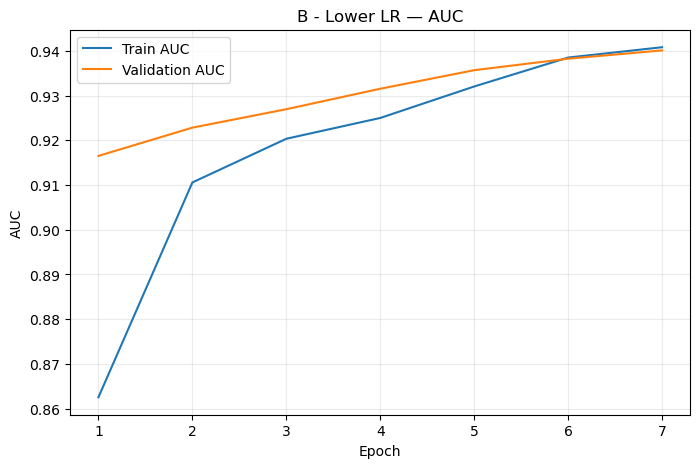

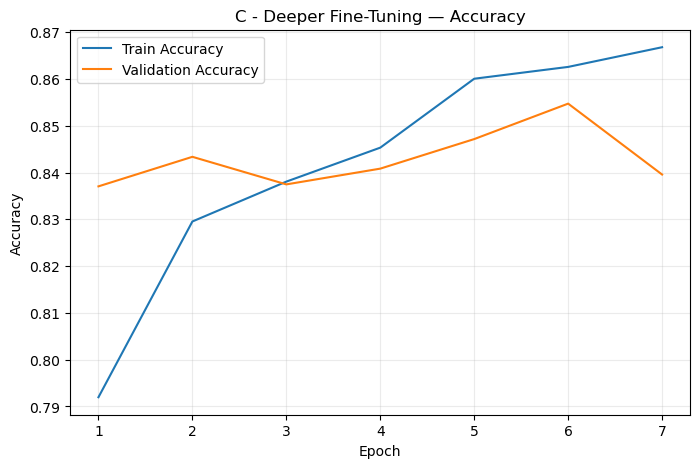

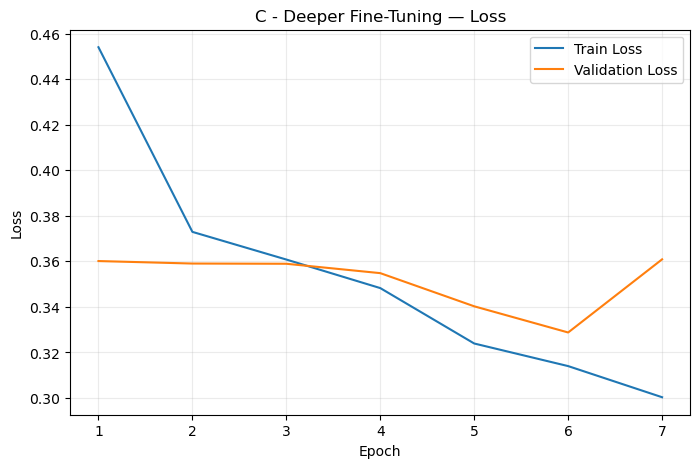

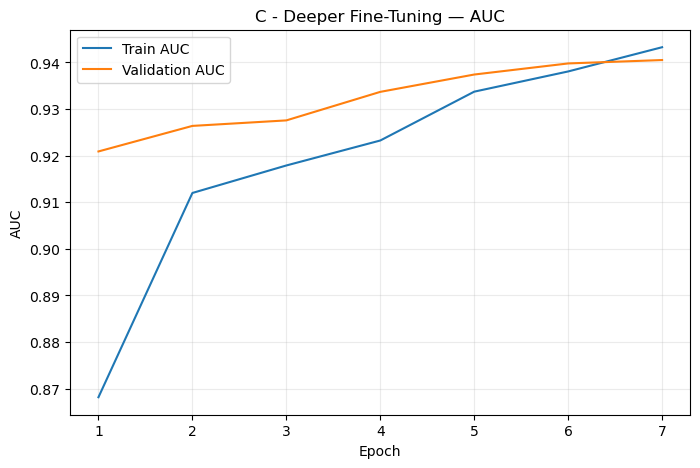

In [10]:
for experiment_name, history in experiment_histories.items():
    plot_combined_history(history, experiment_name)



<a id="section8"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Experiment Log &amp; Validation-Based Selection</h2>

Every configuration and validation result is recorded in a table and exported to CSV.

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>Model-selection discipline:</b> Sort by validation AUC. Do not use the test set to decide which experiment wins.
</div>


In [11]:
experiment_log = experiment_log.sort_values(
    "best_val_auc",
    ascending=False,
).reset_index(drop=True)

display(experiment_log.style.format({
    "fine_tune_lr": "{:.1e}",
    "dropout": "{:.2f}",
    "best_val_auc": "{:.4f}",
    "best_val_accuracy": "{:.4f}",
    "best_val_recall": "{:.4f}",
    "best_val_precision": "{:.4f}",
    "training_seconds": "{:.1f}",
}))

log_path = ARTIFACTS_DIR / "day5_experiment_log.csv"
experiment_log.to_csv(log_path, index=False)

SELECTED_EXPERIMENT = experiment_log.loc[0, "experiment"]
SELECTED_MODEL_PATH = experiment_model_paths[SELECTED_EXPERIMENT]

print("Selected experiment:", SELECTED_EXPERIMENT)
print("Selection metric    : validation AUC")
print("Model path          :", SELECTED_MODEL_PATH)
print("Experiment log      :", log_path)


,experiment,fine_tune_layers,fine_tune_lr,dropout,epochs_run,best_val_auc,best_val_accuracy,best_val_recall,best_val_precision,training_seconds,trainable_parameters
0,A - Day2 Control,30,1.0e-05,0.30,7,0.9420,0.8581,0.8140,0.9175,963.3,1512001
1,C - Deeper Fine-Tuning,40,5.0e-06,0.30,7,0.9405,0.8547,0.7808,0.9235,1224.4,1664641
2,B - Lower LR,30,5.0e-06,0.30,7,0.9401,0.8577,0.8079,0.9104,1118.1,1512001


Selected experiment: A - Day2 Control
Selection metric    : validation AUC
Model path          : artifacts\models\a_-_day2_control.keras
Experiment log      : artifacts\day5_experiment_log.csv


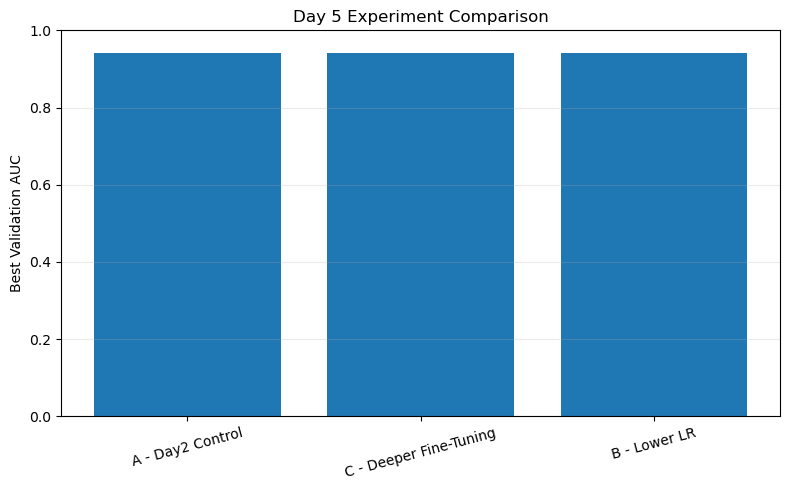

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(experiment_log["experiment"], experiment_log["best_val_auc"])
plt.ylabel("Best Validation AUC")
plt.title("Day 5 Experiment Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



<a id="section9"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Final Test Evaluation of the Selected Model</h2>

Only after the experiment winner is selected from validation results do we evaluate it on the test set.

<div style="border-left:5px solid #D96C5F; background-color:#FCEDEA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7C3A33;">
<b>Important:</b> The test metrics below are final evidence. They should not be used to go back and choose another experiment.
</div>


In [13]:
selected_model = keras.models.load_model(SELECTED_MODEL_PATH)

test_metrics = selected_model.evaluate(
    test_ds,
    verbose=0,
    return_dict=True,
)

final_test_row = {
    "model": SELECTED_EXPERIMENT,
    "test_loss": float(test_metrics["loss"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_auc": float(test_metrics["auc"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
}

pd.DataFrame([final_test_row]).style.format({
    "test_loss": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_auc": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
})


,model,test_loss,test_accuracy,test_auc,test_precision,test_recall
0,A - Day2 Control,0.3673,0.8375,0.9513,0.9400,0.7210


Selected model: A - Day2 Control

Classification report:

              precision    recall  f1-score   support

      Benign     0.7737    0.9540    0.8545      1000
   Malignant     0.9400    0.7210    0.8161      1000

    accuracy                         0.8375      2000
   macro avg     0.8569    0.8375    0.8353      2000
weighted avg     0.8569    0.8375    0.8353      2000



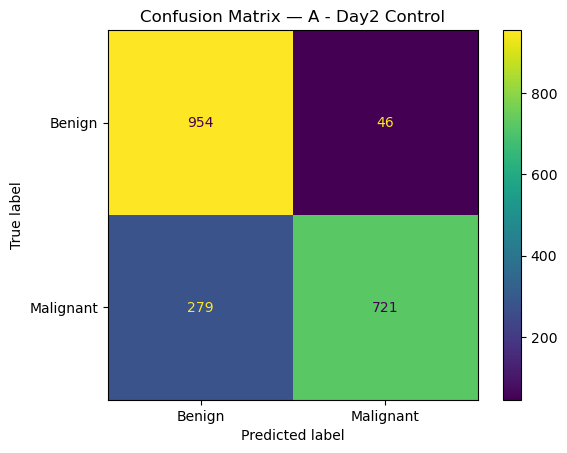

In [14]:
true_labels = np.concatenate(
    [labels.numpy().ravel() for _, labels in test_ds]
).astype(int)

test_probabilities = selected_model.predict(
    test_ds,
    verbose=0,
).ravel()

test_predictions = (test_probabilities >= 0.50).astype(int)

print("Selected model:", SELECTED_EXPERIMENT)
print("\nClassification report:\n")
print(classification_report(
    true_labels,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
))

cm = confusion_matrix(true_labels, test_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
).plot(values_format="d")

plt.title(f"Confusion Matrix — {SELECTED_EXPERIMENT}")
plt.show()



<a id="section10"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Threshold Analysis</h2>

The default sigmoid threshold is <code>0.50</code>.  
This section does <b>not</b> retrain the model. It shows how the decision threshold changes precision and recall.

<div style="border-left:5px solid #D8A94A; background-color:#FFF7E1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#6A5420;">
<b>Why include this?</b> The Day 2 best model had strong Malignant precision but lower Malignant recall.
Threshold analysis helps explain the trade-off between catching more positive cases and producing more false positives.
</div>


In [15]:
# Use validation data for threshold exploration.
val_true = np.concatenate(
    [labels.numpy().ravel() for _, labels in val_ds]
).astype(int)

val_probabilities = selected_model.predict(
    val_ds,
    verbose=0,
).ravel()

threshold_rows = []

for threshold in np.arange(0.30, 0.71, 0.05):
    preds = (val_probabilities >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(val_true, preds),
        "precision": precision_score(val_true, preds, zero_division=0),
        "recall": recall_score(val_true, preds, zero_division=0),
        "f1": f1_score(val_true, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.style.format({
    "threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
}))


,threshold,accuracy,precision,recall,f1
0,0.30,0.5032,0.4843,0.4725,0.4783
1,0.35,0.5032,0.4836,0.4498,0.4661
2,0.40,0.5036,0.4834,0.4323,0.4564
3,0.45,0.5011,0.4799,0.4175,0.4465
4,0.50,0.5002,0.4778,0.3948,0.4323
5,0.55,0.4989,0.4751,0.3755,0.4195
6,0.60,0.4989,0.4742,0.3607,0.4097
7,0.65,0.4977,0.4716,0.3485,0.4008
8,0.70,0.4952,0.4662,0.3249,0.3829


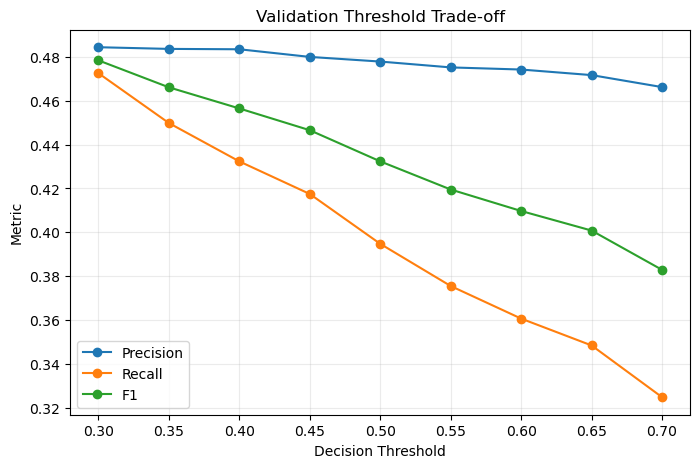

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.title("Validation Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.25)
plt.show()



<div style="border-left:5px solid #D96C5F; background-color:#FCEDEA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7C3A33;">
<b>Evaluation rule:</b> If a threshold is selected, it must be selected from <b>validation data only</b>.
Do not search the test set for the threshold that gives the best result.
</div>



<a id="section11"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">11. Sprint 2 Model Comparison</h2>

The final Sprint 2 evidence should distinguish <b>historical Day 2 results</b> from the newly evaluated Day 5 model.


In [17]:
day2_reference = pd.DataFrame([
    {
        "model": "Scratch CNN (Day 2)",
        "test_accuracy": 0.7805,
        "test_auc": 0.8838,
        "test_precision": 0.8288,
        "test_recall": 0.7070,
        "source": "Documented Day 2 result",
    },
    {
        "model": "Frozen MobileNetV2 (Day 2)",
        "test_accuracy": 0.8480,
        "test_auc": 0.9390,
        "test_precision": 0.9123,
        "test_recall": 0.7700,
        "source": "Documented Day 2 result",
    },
    {
        "model": "MobileNetV2 + Fine-Tuning (Day 2)",
        "test_accuracy": 0.8625,
        "test_auc": 0.9499,
        "test_precision": 0.9191,
        "test_recall": 0.7950,
        "source": "Documented Day 2 result",
    },
])

day5_reference = pd.DataFrame([{
    "model": f"{SELECTED_EXPERIMENT} (Day 5)",
    "test_accuracy": final_test_row["test_accuracy"],
    "test_auc": final_test_row["test_auc"],
    "test_precision": final_test_row["test_precision"],
    "test_recall": final_test_row["test_recall"],
    "source": "Day 5 final test evaluation",
}])

sprint2_comparison = pd.concat(
    [day2_reference, day5_reference],
    ignore_index=True,
)

display(sprint2_comparison.style.format({
    "test_accuracy": "{:.4f}",
    "test_auc": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
}))


,model,test_accuracy,test_auc,test_precision,test_recall,source
0,Scratch CNN (Day 2),0.7805,0.8838,0.8288,0.7070,Documented Day 2 result
1,Frozen MobileNetV2 (Day 2),0.8480,0.9390,0.9123,0.7700,Documented Day 2 result
2,MobileNetV2 + Fine-Tuning (Day 2),0.8625,0.9499,0.9191,0.7950,Documented Day 2 result
3,A - Day2 Control (Day 5),0.8375,0.9513,0.9400,0.7210,Day 5 final test evaluation


In [18]:
day2_best_auc = 0.9499
day2_best_accuracy = 0.8625

auc_change = final_test_row["test_auc"] - day2_best_auc
accuracy_change = final_test_row["test_accuracy"] - day2_best_accuracy

print("Change vs Day 2 fine-tuned MobileNetV2")
print(f"AUC change     : {auc_change:+.4f}")
print(f"Accuracy change: {accuracy_change:+.4f}")


Change vs Day 2 fine-tuned MobileNetV2
AUC change     : +0.0014
Accuracy change: -0.0250



<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>How to interpret this section:</b> Improvement is not assumed. If Day 5 does not beat the Day 2 reference,
document that result honestly and explain which tuning settings were tested. A reproducible negative result is still useful evidence.
</div>



<a id="section13"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">13. Sprint Review</h2>

After running the notebook, complete the review with the values produced above.

<div style="border-left:5px solid #2F6B5B; background-color:#EDF6F3; padding:12px 16px; margin:10px 0; border-radius:4px; color:#153B32;">
<b>Sprint Review Template</b>
<ul style="line-height:1.8;">
<li><b>Project data type:</b> Images.</li>
<li><b>Selected architecture:</b> CNN with MobileNetV2 transfer learning.</li>
<li><b>Day 2 best reference:</b> Fine-tuned MobileNetV2 — Accuracy 0.8625, AUC 0.9499.</li>
<li><b>Day 5 experiments:</b> Control fine-tuning, lower learning rate, and deeper fine-tuning.</li>
<li><b>Selected Day 5 experiment:</b> A - Day2 Control</li>
<li><b>Final Day 5 Accuracy:</b> 0.8375</li>
<li><b>Final Day 5 AUC:</b> 0.9513</li>
<li><b>Final Day 5 Precision:</b> 0.9400</li>
<li><b>Final Day 5 Recall:</b> 0.7210</li>
<li><b>Result vs Day 2:</b> AUC improved by +0.0014, while accuracy decreased by -0.0250. Overall, there was no clear improvement across all metrics.</li>
</ul>
</div>

### Sprint Review Conclusion

**Sprint Review Conclusion:**  
Experiment A — Day2 Control was selected because it achieved the highest validation AUC among the Day 5 experiments. On the test set, it achieved **0.8375 accuracy**, **0.9513 AUC**, **0.9400 precision**, and **0.7210 recall**. Compared with the Day 2 fine-tuned MobileNetV2, the AUC improved slightly by **+0.0014**, while accuracy decreased by **0.0250** and recall decreased from **0.7950 to 0.7210**. Therefore, the Day 5 tuning did not produce a clear overall improvement; it slightly improved ranking performance but reduced classification balance.



<a id="section14"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">14. Retrospective</h2>

The retrospective should describe what happened during the sprint and identify one concrete change for Sprint 3.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr><th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Question</th><th style="background-color:#2F6B5B; color:#F6E7B0; padding:8px; text-align:left;">Reflection</th></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>What went well?</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Transfer learning gave a strong starting point and the experiments were controlled and logged.</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>What was difficult?</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Fine-tuning multiple CNN configurations is computationally expensive, especially on CPU.</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>What did the metrics reveal?</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">The selected Day 5 model achieved a slightly higher AUC than the Day 2 fine-tuned MobileNetV2, but its accuracy and recall were lower. This shows that the tuning improved ranking performance slightly, but did not improve the model consistently across all evaluation metrics.</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>One concrete Sprint 3 change</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Use the selected model and focus the next sprint on robust evaluation/error analysis instead of adding unrelated architectures.</td></tr>
</table>
</div>

### Retrospective Note

**Retrospective Note:**  
During Sprint 2, MobileNetV2 with transfer learning remained the most appropriate architecture for the image-classification project. The controlled fine-tuning experiments showed that lowering the learning rate or unfreezing more layers did not outperform the control experiment on validation AUC. The final Day 5 model achieved a slightly higher AUC than the Day 2 model, but accuracy and recall decreased, so the tuning did not create a clear overall improvement. For Sprint 3, I would focus on error analysis and stronger evaluation before making additional architecture changes.



<a id="section16"></a>
<h2 style="color:#F6E7B0; background-color:#2F6B5B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">16. What I Learned Today</h2>

<div style="border-left:5px solid #4F9D8A; background-color:#EAF5F1; padding:10px 15px; margin:10px 0; border-radius:4px; color:#24554A;">
<b>Day 5 Summary:</b> I moved from learning individual architectures to making and defending an engineering decision:
select the architecture that matches the data, tune it through controlled experiments, log the evidence,
choose using validation results, and evaluate the final model once on the test set.
</div>

- I confirmed that CNN + transfer learning is the correct core architecture for the image project.
- I used the Day 2 fine-tuned MobileNetV2 as the documented starting point.
- I designed controlled fine-tuning experiments instead of changing many variables at once.
- I logged validation AUC, accuracy, precision, recall, training time, and configuration settings.
- I selected the winning experiment using validation performance rather than test results.
- I evaluated the selected model using final test metrics and a confusion matrix.
- I analyzed the precision/recall effect of changing the classification threshold.
- I assembled Sprint Review evidence and completed a Retrospective for the next sprint.



<p style="text-align:right; margin-top:18px;">
<a href="#toc" style="color:#2F6B5B; font-weight:bold; text-decoration:none;">↑ Back to Table of Contents</a>
</p>
